In [1]:
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Upload and Load Dataset

In [2]:
# Upload dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

if file_name.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name, encoding_errors="ignore")

print("Dataset shape:", df.shape)
display(df.head())

Saving MAI_GP_kc_house_data.xlsx to MAI_GP_kc_house_data.xlsx
Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 2. Basic Dataset Checking

In [3]:
print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## 3. Data Preprocessing and Feature Engineering


In [4]:
# Data preprocessing
df_model = df.copy()

# Convert date column and extract simple time features
if "date" in df_model.columns:
    df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")
    df_model["year"] = df_model["date"].dt.year
    df_model["month"] = df_model["date"].dt.month

# Remove unnecessary identifier/date columns
drop_cols = [col for col in ["id", "date"] if col in df_model.columns]
df_model = df_model.drop(columns=drop_cols)

# Remove missing values and invalid target values
df_model = df_model.dropna()
df_model = df_model[df_model["price"] > 0]

# Feature engineering
if "yr_built" in df_model.columns:
    df_model["age"] = 2014 - df_model["yr_built"]

if "yr_renovated" in df_model.columns:
    df_model["is_renovated"] = (df_model["yr_renovated"] > 0).astype(int)

if {"bedrooms", "bathrooms"}.issubset(df_model.columns):
    df_model["total_rooms"] = df_model["bedrooms"] + df_model["bathrooms"]

if {"sqft_living", "sqft_lot"}.issubset(df_model.columns):
    df_model["living_to_lot_ratio"] = df_model["sqft_living"] / df_model["sqft_lot"]

if {"sqft_living", "floors"}.issubset(df_model.columns):
    df_model["sqft_per_floor"] = df_model["sqft_living"] / df_model["floors"]

print("After preprocessing:", df_model.shape)
display(df_model.head())

After preprocessing: (21613, 26)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,age,is_renovated,total_rooms,living_to_lot_ratio,sqft_per_floor
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,59,0,4.00,0.208850,1180.0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,63,1,5.25,0.354874,1285.0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,81,0,3.00,0.077000,770.0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,49,0,7.00,0.392000,1960.0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,27,0,5.00,0.207921,1680.0


## 4. Feature Selection and Zipcode One-Hot Encoding

In [5]:
target_col = "price"

selected_features = [
    # house structure features
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "condition",
    "grade",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated",

    # engineered features
    "age",
    "is_renovated",
    "total_rooms",
    "living_to_lot_ratio",
    "sqft_per_floor",

    # location-related features
    "zipcode",
    "lat",
    "long",
    "waterfront",
    "view",
    "sqft_living15",
    "sqft_lot15",

    # time features
    "year",
    "month"
]

# Keep only features that exist in the dataset
selected_features = [f for f in selected_features if f in df_model.columns]

X = df_model[selected_features].copy()
y = df_model[target_col]

# Zipcode is a location category, not a continuous numerical feature.
# Therefore, one-hot encoding is used.
if "zipcode" in X.columns:
    X["zipcode"] = X["zipcode"].astype(str)
    X = pd.get_dummies(X, columns=["zipcode"], drop_first=True)

# Make sure all features are numeric
X = X.astype(float)

print("Selected original features:")
print(selected_features)

print("\nFinal feature number after zipcode one-hot encoding:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Selected original features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'age', 'is_renovated', 'total_rooms', 'living_to_lot_ratio', 'sqft_per_floor', 'zipcode', 'lat', 'long', 'waterfront', 'view', 'sqft_living15', 'sqft_lot15', 'year', 'month']

Final feature number after zipcode one-hot encoding: 93
X shape: (21613, 93)
y shape: (21613,)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,age,is_renovated,total_rooms,living_to_lot_ratio,sqft_per_floor,lat,long,waterfront,view,sqft_living15,sqft_lot15,year,month,zipcode_98002,zipcode_98003,zipcode_98004,zipcode_98005,zipcode_98006,zipcode_98007,zipcode_98008,zipcode_98010,zipcode_98011,zipcode_98014,zipcode_98019,zipcode_98022,zipcode_98023,zipcode_98024,zipcode_98027,zipcode_98028,zipcode_98029,zipcode_98030,zipcode_98031,zipcode_98032,zipcode_98033,zipcode_98034,zipcode_98038,zipcode_98039,zipcode_98040,zipcode_98042,zipcode_98045,zipcode_98052,zipcode_98053,zipcode_98055,zipcode_98056,zipcode_98058,zipcode_98059,zipcode_98065,zipcode_98070,zipcode_98072,zipcode_98074,zipcode_98075,zipcode_98077,zipcode_98092,zipcode_98102,zipcode_98103,zipcode_98105,zipcode_98106,zipcode_98107,zipcode_98108,zipcode_98109,zipcode_98112,zipcode_98115,zipcode_98116,zipcode_98117,zipcode_98118,zipcode_98119,zipcode_98122,zipcode_98125,zipcode_98126,zipcode_98133,zipcode_98136,zipcode_98144,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,3.0,1.00,1180.0,5650.0,1.0,3.0,7.0,1180.0,0.0,1955.0,0.0,59.0,0.0,4.00,0.208850,1180.0,47.5112,-122.257,0.0,0.0,1340.0,5650.0,2014.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,3.0,2.25,2570.0,7242.0,2.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,63.0,1.0,5.25,0.354874,1285.0,47.7210,-122.319,0.0,0.0,1690.0,7639.0,2014.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,1.00,770.0,10000.0,1.0,3.0,6.0,770.0,0.0,1933.0,0.0,81.0,0.0,3.00,0.077000,770.0,47.7379,-122.233,0.0,0.0,2720.0,8062.0,2015.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,3.00,1960.0,5000.0,1.0,5.0,7.0,1050.0,910.0,1965.0,0.0,49.0,0.0,7.00,0.392000,1960.0,47.5208,-122.393,0.0,0.0,1360.0,5000.0,2014.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,2.00,1680.0,8080.0,1.0,3.0,8.0,1680.0,0.0,1987.0,0.0,27.0,0.0,5.00,0.207921,1680.0,47.6168,-122.045,0.0,0.0,1800.0,7503.0,2015.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Train / Validation / Test Split

In [6]:
# Log-transform price
y_log = np.log1p(y)

# 60% training, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_log,
    test_size=0.4,
    random_state=42
)

# 20% validation, 20% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Train shape      :", X_train.shape)
print("Validation shape :", X_val.shape)
print("Test shape       :", X_test.shape)

Train shape      : (12967, 93)
Validation shape : (4323, 93)
Test shape       : (4323, 93)


## 6. Evaluation Function with MAE, RMSE, R², and MAPE

MAPE is useful because house prices have a wide range.  
A fixed dollar error may be small for a high-value house but large for a low-value house.


In [7]:
def evaluate_regression(y_true_log, y_pred_log):
    """Evaluate predictions in the original dollar price scale."""

    # Convert log price back to original dollar price
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE = average percentage error
    # epsilon avoids division by zero
    epsilon = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

    return r2, mae, rmse, mape

## 7. Train XGBoost Models

In [8]:
common_params = {
    "learning_rate": 0.05,
    "max_depth": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
}

In [9]:
# Model A: XGBoost without early stopping
model_no_es = XGBRegressor(
    n_estimators=500,
    **common_params
)

model_no_es.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

results_no_es = model_no_es.evals_result()

y_val_pred_no_es = model_no_es.predict(X_val)
y_test_pred_no_es = model_no_es.predict(X_test)

val_metrics_no_es = evaluate_regression(y_val, y_val_pred_no_es)
test_metrics_no_es = evaluate_regression(y_test, y_test_pred_no_es)

print("Validation metrics without early stopping:")
print("R2   :", val_metrics_no_es[0])
print("MAE  :", val_metrics_no_es[1])
print("RMSE :", val_metrics_no_es[2])
print("MAPE :", val_metrics_no_es[3], "%")

print("\nTest metrics without early stopping:")
print("R2   :", test_metrics_no_es[0])
print("MAE  :", test_metrics_no_es[1])
print("RMSE :", test_metrics_no_es[2])
print("MAPE :", test_metrics_no_es[3], "%")

Validation metrics without early stopping:
R2   : 0.8926819502239143
MAE  : 63531.372856667826
RMSE : 118526.6342714016
MAPE : 11.718182698529612 %

Test metrics without early stopping:
R2   : 0.9130444624104322
MAE  : 64577.57318413139
RMSE : 120873.24537544737
MAPE : 11.714860328832218 %


In [10]:
# Model B: XGBoost with early stopping
model_es = XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=20,
    **common_params
)

model_es.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

results_es = model_es.evals_result()

y_val_pred_es = model_es.predict(X_val)
y_test_pred_es = model_es.predict(X_test)

val_metrics_es = evaluate_regression(y_val, y_val_pred_es)
test_metrics_es = evaluate_regression(y_test, y_test_pred_es)

print("Validation metrics with early stopping:")
print("R2   :", val_metrics_es[0])
print("MAE  :", val_metrics_es[1])
print("RMSE :", val_metrics_es[2])
print("MAPE :", val_metrics_es[3], "%")

print("\nTest metrics with early stopping:")
print("R2   :", test_metrics_es[0])
print("MAE  :", test_metrics_es[1])
print("RMSE :", test_metrics_es[2])
print("MAPE :", test_metrics_es[3], "%")

Validation metrics with early stopping:
R2   : 0.8941629237959577
MAE  : 63191.86409900532
RMSE : 117705.96795768772
MAPE : 11.661689719994081 %

Test metrics with early stopping:
R2   : 0.913564059952648
MAE  : 64319.46513380466
RMSE : 120511.56889771274
MAPE : 11.669205502347628 %


## 8. Model Comparison Table

In [11]:
comparison_df = pd.DataFrame({
    "Model": ["No Early Stopping", "With Early Stopping"],

    "Val R2": [val_metrics_no_es[0], val_metrics_es[0]],
    "Val MAE": [val_metrics_no_es[1], val_metrics_es[1]],
    "Val RMSE": [val_metrics_no_es[2], val_metrics_es[2]],
    "Val MAPE (%)": [val_metrics_no_es[3], val_metrics_es[3]],

    "Test R2": [test_metrics_no_es[0], test_metrics_es[0]],
    "Test MAE": [test_metrics_no_es[1], test_metrics_es[1]],
    "Test RMSE": [test_metrics_no_es[2], test_metrics_es[2]],
    "Test MAPE (%)": [test_metrics_no_es[3], test_metrics_es[3]],
})

display(comparison_df)

print("Best iteration:", model_es.best_iteration)
print("Best validation score:", model_es.best_score)
print("Best iteration ratio:", round((model_es.best_iteration + 1) / 1000, 4))

,Model,Val R2,Val MAE,Val RMSE,Val MAPE (%),Test R2,Test MAE,Test RMSE,Test MAPE (%)
0,No Early Stopping,0.892682,63531.372857,118526.634271,11.718183,0.913044,64577.573184,120873.245375,11.714860
1,With Early Stopping,0.894163,63191.864099,117705.967958,11.661690,0.913564,64319.465134,120511.568898,11.669206


Best iteration: 554
Best validation score: 0.16180216051950336
Best iteration ratio: 0.555


## 9. Training Curves

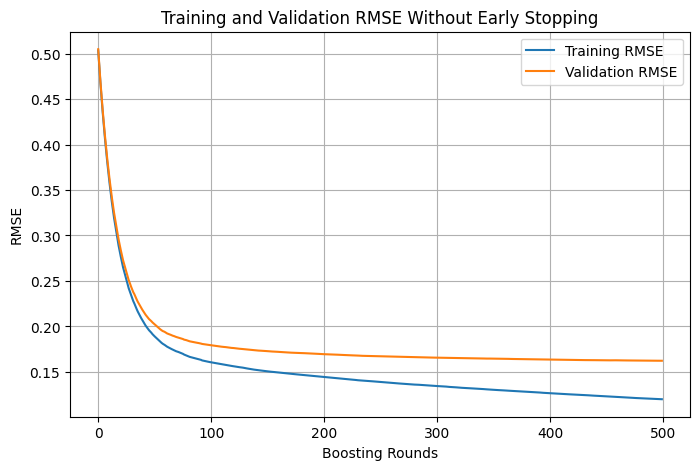

In [12]:
# Training and validation RMSE without early stopping
train_rmse_no_es = results_no_es["validation_0"]["rmse"]
val_rmse_no_es = results_no_es["validation_1"]["rmse"]

plt.figure(figsize=(8, 5))
plt.plot(train_rmse_no_es, label="Training RMSE")
plt.plot(val_rmse_no_es, label="Validation RMSE")
plt.title("Training and Validation RMSE Without Early Stopping")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

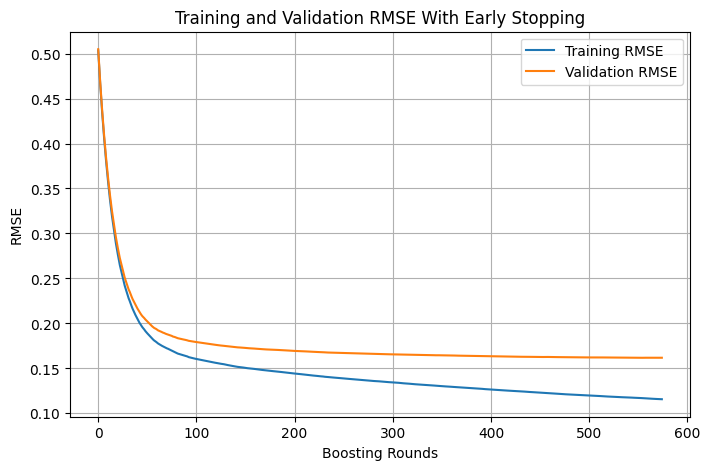

In [13]:
# Training and validation RMSE with early stopping
train_rmse_es = results_es["validation_0"]["rmse"]
val_rmse_es = results_es["validation_1"]["rmse"]

plt.figure(figsize=(8, 5))
plt.plot(train_rmse_es, label="Training RMSE")
plt.plot(val_rmse_es, label="Validation RMSE")
plt.title("Training and Validation RMSE With Early Stopping")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

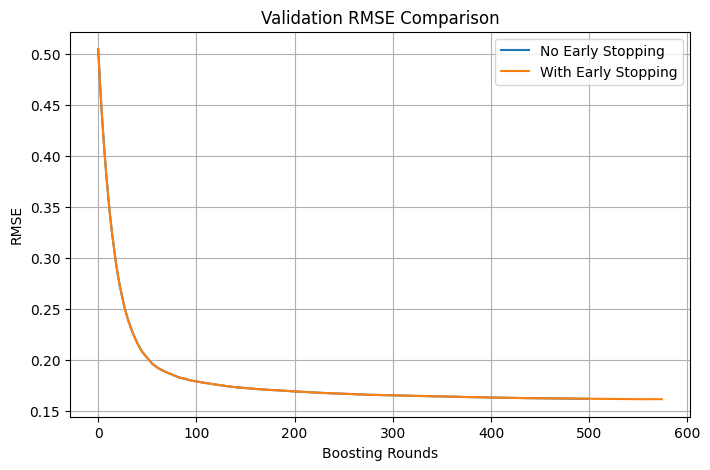

In [14]:
# Validation RMSE comparison
plt.figure(figsize=(8, 5))
plt.plot(val_rmse_no_es, label="No Early Stopping")
plt.plot(val_rmse_es, label="With Early Stopping")
plt.title("Validation RMSE Comparison")
plt.xlabel("Boosting Rounds")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

## 10. Actual vs Predicted Price

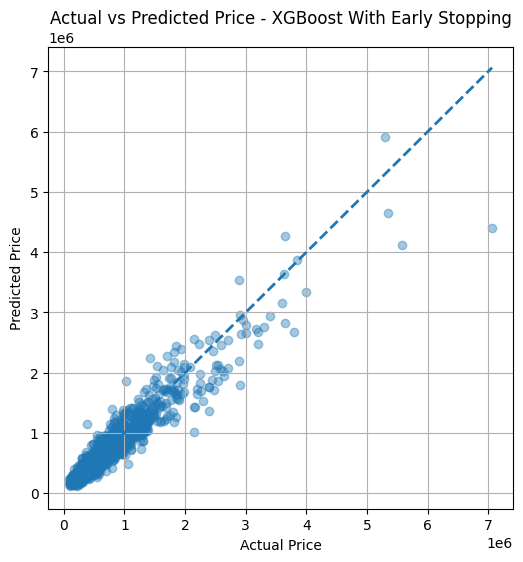

In [15]:
y_test_true = np.expm1(y_test)
y_test_pred = np.expm1(model_es.predict(X_test))

plt.figure(figsize=(6, 6))
plt.scatter(y_test_true, y_test_pred, alpha=0.4)
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()],
    "--",
    linewidth=2
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price - XGBoost With Early Stopping")
plt.grid(True)
plt.show()

## 11. Feature Importance

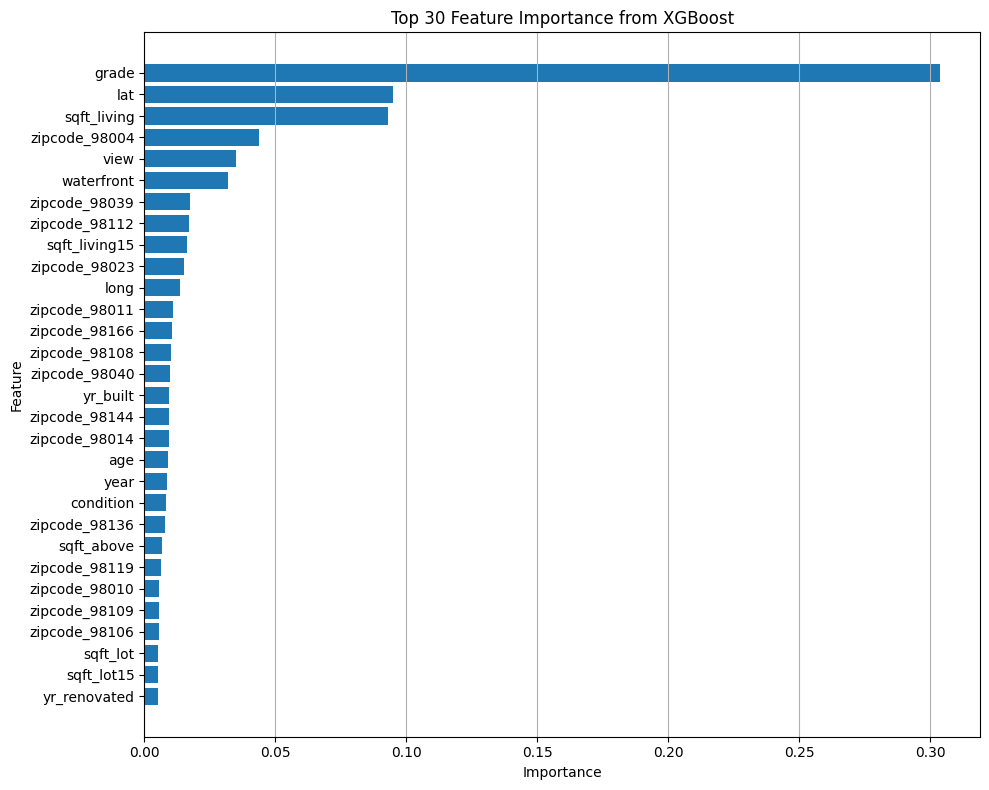

,feature,importance
0,grade,0.303824
1,lat,0.095023
2,sqft_living,0.092998
3,zipcode_98004,0.043709
4,view,0.035090
5,waterfront,0.031976
6,zipcode_98039,0.017470
7,zipcode_98112,0.016993
8,sqft_living15,0.016156
9,zipcode_98023,0.015250


In [16]:
feature_importance = pd.Series(
    model_es.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_n = 30
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features.index, top_features.values)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importance from XGBoost")
plt.gca().invert_yaxis()
plt.grid(True, axis="x")
plt.tight_layout()
plt.show()

display(top_features.reset_index().rename(columns={"index": "feature", 0: "importance"}))

# Zipcode-Level Fairness and Stability Analysis


In [17]:
# 1. Build test result dataframe
location_result = pd.DataFrame({
    "actual_price": y_test_true,
    "predicted_price": y_test_pred
}, index=X_test.index)

# 2. Get original zipcode from df_model
location_result["zipcode"] = df_model.loc[X_test.index, "zipcode"].astype(str).values

# 3. Calculate error metrics for each house
location_result["absolute_error"] = np.abs(
    location_result["actual_price"] - location_result["predicted_price"]
)

location_result["squared_error"] = (
    location_result["actual_price"] - location_result["predicted_price"]
) ** 2

location_result["percentage_error"] = (
    location_result["absolute_error"] / location_result["actual_price"]
) * 100

# Positive bias means over-prediction.
# Negative bias means under-prediction.
location_result["prediction_bias"] = (
    location_result["predicted_price"] - location_result["actual_price"]
)

display(location_result.head())

,actual_price,predicted_price,zipcode,absolute_error,squared_error,percentage_error,prediction_bias
5133,770000.0,6.984140e+05,98065,71586.00000,5.124555e+09,9.296883,-71586.00000
16862,1200000.0,1.267165e+06,98053,67165.37500,4.511188e+09,5.597115,67165.37500
12521,745000.0,7.662521e+05,98004,21252.06250,4.516502e+08,2.852626,21252.06250
2081,192500.0,1.875462e+05,98168,4953.84375,2.454057e+07,2.573425,-4953.84375
18002,969950.0,1.029229e+06,98117,59278.75000,3.513970e+09,6.111526,59278.75000


In [18]:
# Calculate zipcode-level performance
zipcode_performance = location_result.groupby("zipcode").agg(
    sample_count=("actual_price", "count"),
    mean_actual_price=("actual_price", "mean"),
    mean_predicted_price=("predicted_price", "mean"),
    MAE=("absolute_error", "mean"),
    RMSE=("squared_error", lambda x: np.sqrt(np.mean(x))),
    MAPE=("percentage_error", "mean"),
    mean_bias=("prediction_bias", "mean")
).reset_index()

# Sort by MAPE from highest to lowest
zipcode_performance = zipcode_performance.sort_values("MAPE", ascending=False)

display(zipcode_performance.head(20))

,zipcode,sample_count,mean_actual_price,mean_predicted_price,MAE,RMSE,MAPE,mean_bias
61,98148,12,2.929958e+05,2.846207e+05,51001.084635,66463.799658,23.186042,-8375.102865
60,98146,53,3.260339e+05,3.252706e+05,61523.421580,87878.315890,21.134482,-763.262382
63,98166,57,5.073702e+05,5.364719e+05,99532.911458,174461.112181,20.905028,29101.780976
64,98168,54,2.458565e+05,2.555553e+05,40481.850405,53703.710650,17.975535,9698.753183
44,98106,61,3.117914e+05,3.062230e+05,49391.223105,66405.264046,17.894946,-5568.430072
30,98055,55,3.043409e+05,3.121032e+05,44102.898011,55320.702057,16.613161,7762.255966
46,98108,33,3.344406e+05,3.364388e+05,43117.187027,52412.698883,15.957423,1998.179451
10,98014,25,4.686960e+05,4.540651e+05,73435.143125,130492.518879,15.853085,-14630.899375
52,98118,106,4.458410e+05,4.318596e+05,71498.358048,134314.042114,15.828542,-13981.426445
35,98070,22,4.918025e+05,4.595553e+05,79306.481534,102992.167786,15.502552,-32247.169034


## 12. Filter Zipcodes with Enough Test Samples

Small-sample zipcodes can be unstable.  
The default threshold is 20 test samples per zipcode.


In [19]:
min_samples = 20

zipcode_performance_stable = zipcode_performance[
    zipcode_performance["sample_count"] >= min_samples
].copy()

zipcode_performance_stable = zipcode_performance_stable.sort_values(
    "MAPE",
    ascending=False
)

print("Number of zipcodes before filtering:", zipcode_performance.shape[0])
print("Number of zipcodes after filtering :", zipcode_performance_stable.shape[0])

display(zipcode_performance_stable.head(20))

Number of zipcodes before filtering: 70
Number of zipcodes after filtering : 66


,zipcode,sample_count,mean_actual_price,mean_predicted_price,MAE,RMSE,MAPE,mean_bias
60,98146,53,3.260339e+05,3.252706e+05,61523.421580,87878.315890,21.134482,-763.262382
63,98166,57,5.073702e+05,5.364719e+05,99532.911458,174461.112181,20.905028,29101.780976
64,98168,54,2.458565e+05,2.555553e+05,40481.850405,53703.710650,17.975535,9698.753183
44,98106,61,3.117914e+05,3.062230e+05,49391.223105,66405.264046,17.894946,-5568.430072
30,98055,55,3.043409e+05,3.121032e+05,44102.898011,55320.702057,16.613161,7762.255966
46,98108,33,3.344406e+05,3.364388e+05,43117.187027,52412.698883,15.957423,1998.179451
10,98014,25,4.686960e+05,4.540651e+05,73435.143125,130492.518879,15.853085,-14630.899375
52,98118,106,4.458410e+05,4.318596e+05,71498.358048,134314.042114,15.828542,-13981.426445
35,98070,22,4.918025e+05,4.595553e+05,79306.481534,102992.167786,15.502552,-32247.169034
27,98045,50,4.193499e+05,4.209444e+05,62475.157500,96749.029558,15.108877,1594.505625


## 13. Worst and Best Zipcodes by MAPE

In [20]:
# Worst 10 zipcodes by MAPE
worst_zipcodes = zipcode_performance_stable.sort_values(
    "MAPE",
    ascending=False
).head(10)

print("Worst 10 zipcodes by MAPE:")
display(worst_zipcodes)

# Best 10 zipcodes by MAPE
best_zipcodes = zipcode_performance_stable.sort_values(
    "MAPE",
    ascending=True
).head(10)

print("\nBest 10 zipcodes by MAPE:")
display(best_zipcodes)

Worst 10 zipcodes by MAPE:


,zipcode,sample_count,mean_actual_price,mean_predicted_price,MAE,RMSE,MAPE,mean_bias
60,98146,53,326033.886792,325270.59375,61523.421580,87878.315890,21.134482,-763.262382
63,98166,57,507370.175439,536471.93750,99532.911458,174461.112181,20.905028,29101.780976
64,98168,54,245856.518519,255555.28125,40481.850405,53703.710650,17.975535,9698.753183
44,98106,61,311791.442623,306223.03125,49391.223105,66405.264046,17.894946,-5568.430072
30,98055,55,304340.909091,312103.15625,44102.898011,55320.702057,16.613161,7762.255966
46,98108,33,334440.636364,336438.81250,43117.187027,52412.698883,15.957423,1998.179451
10,98014,25,468696.000000,454065.12500,73435.143125,130492.518879,15.853085,-14630.899375
52,98118,106,445841.037736,431859.62500,71498.358048,134314.042114,15.828542,-13981.426445
35,98070,22,491802.454545,459555.28125,79306.481534,102992.167786,15.502552,-32247.169034
27,98045,50,419349.860000,420944.37500,62475.157500,96749.029558,15.108877,1594.505625



Best 10 zipcodes by MAPE:


,zipcode,sample_count,mean_actual_price,mean_predicted_price,MAE,RMSE,MAPE,mean_bias
17,98029,61,632463.475410,635640.50000,43900.732582,63451.009210,6.801188,3177.048156
19,98031,65,301223.076923,305070.06250,22113.765144,37984.062982,6.818917,3846.997837
39,98077,47,650202.127660,627319.37500,53649.483378,81529.835854,7.657958,-22882.762633
38,98075,77,776305.688312,778480.06250,65224.356331,91589.807215,7.706038,2174.369318
29,98053,81,731034.160494,714528.06250,66014.078318,127392.575424,8.307391,-16506.133873
37,98074,87,691336.666667,692092.12500,64012.825431,114791.914392,8.580046,755.485632
33,98059,88,502424.852273,489194.50000,42422.167436,60952.216380,8.677604,-13230.345348
45,98107,51,621880.392157,608397.18750,62402.390931,123481.374583,8.765905,-13483.177696
23,98038,111,359913.324324,357935.28125,33964.628097,58386.825318,8.848452,-1978.036881
11,98019,33,430155.303030,435563.90625,32145.369318,42581.749446,8.966335,5408.619318


## 14. Over-Predicted and Under-Predicted Zipcodes

In [21]:
# Most over-predicted zipcodes
over_predicted_zipcodes = zipcode_performance_stable.sort_values(
    "mean_bias",
    ascending=False
).head(10)

print("Most over-predicted zipcodes:")
display(over_predicted_zipcodes)

# Most under-predicted zipcodes
under_predicted_zipcodes = zipcode_performance_stable.sort_values(
    "mean_bias",
    ascending=True
).head(10)

print("\nMost under-predicted zipcodes:")
display(under_predicted_zipcodes)

Most over-predicted zipcodes:


,zipcode,sample_count,mean_actual_price,mean_predicted_price,MAE,RMSE,MAPE,mean_bias
63,98166,57,507370.175439,536471.93750,99532.911458,174461.112181,20.905028,29101.780976
22,98034,115,518457.286957,539406.25000,57886.557880,108145.751811,11.531964,20948.988859
40,98092,71,368359.000000,379305.65625,34891.331206,56212.313068,9.623002,10946.671875
64,98168,54,245856.518519,255555.28125,40481.850405,53703.710650,17.975535,9698.753183
36,98072,51,492125.490196,500232.78125,57488.712623,82095.532926,11.721682,8107.287377
30,98055,55,304340.909091,312103.15625,44102.898011,55320.702057,16.613161,7762.255966
9,98011,42,472955.952381,480656.93750,42959.209449,52262.220351,9.688217,7701.015997
56,98126,76,415027.078947,422667.59375,47888.432771,63238.767979,13.289385,7640.492804
4,98005,32,789156.250000,796624.50000,93785.989258,129125.306670,10.946340,7468.239258
62,98155,74,457808.608108,465160.06250,58659.727196,101379.700857,12.658703,7351.450169



Most under-predicted zipcodes:


,zipcode,sample_count,mean_actual_price,mean_predicted_price,MAE,RMSE,MAPE,mean_bias
53,98119,40,9.190344e+05,8.116929e+05,147075.200781,248655.979801,12.689424,-107341.466406
3,98004,77,1.506270e+06,1.408144e+06,232148.892857,421302.140470,13.999518,-98125.400974
41,98102,20,8.449825e+05,7.928989e+05,122205.189063,162361.612947,13.340771,-52083.673438
43,98105,39,9.316987e+05,8.964291e+05,118312.604968,168217.153126,12.062105,-35269.553686
35,98070,22,4.918025e+05,4.595553e+05,79306.481534,102992.167786,15.502552,-32247.169034
42,98103,125,5.847349e+05,5.567433e+05,69051.744250,88248.967219,11.905978,-27991.617750
21,98033,84,8.110366e+05,7.834798e+05,111356.376116,174339.577700,11.827721,-27556.829985
7,98008,58,6.448103e+05,6.178247e+05,71362.125539,107255.615132,10.558875,-26985.627694
48,98112,60,1.143567e+06,1.119796e+06,141944.899479,198836.764332,13.305999,-23771.022396
54,98122,57,5.663438e+05,5.433513e+05,73924.411184,100829.459029,12.882674,-22992.459430


## 15. Visualisation: Zipcodes with Highest MAPE

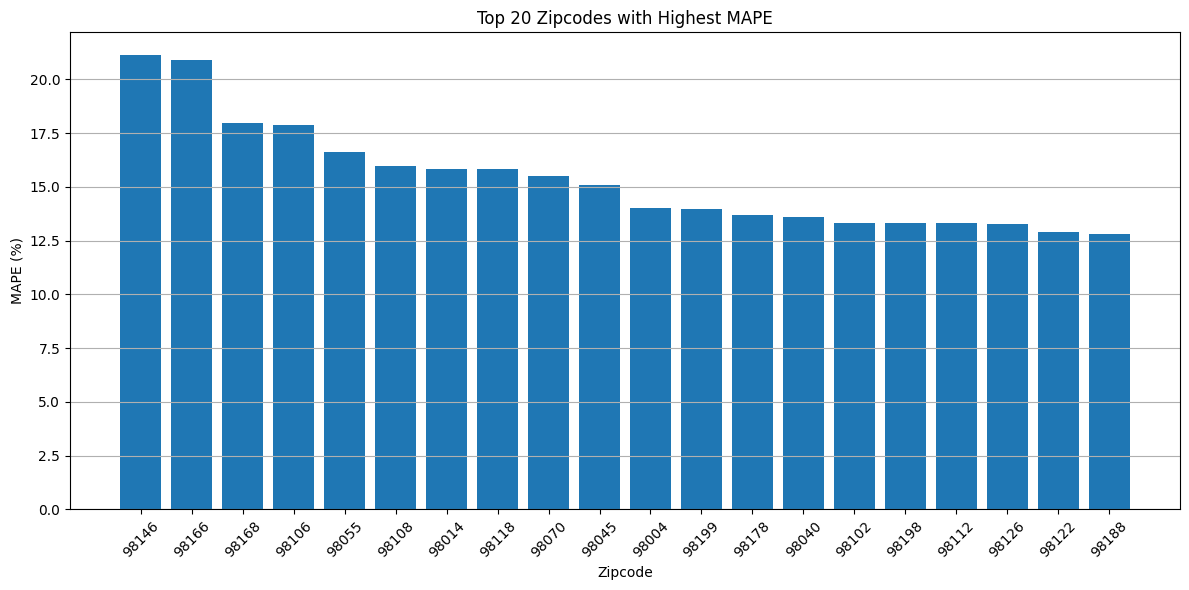

In [22]:
top_mape_zipcodes = zipcode_performance_stable.sort_values(
    "MAPE",
    ascending=False
).head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_mape_zipcodes["zipcode"], top_mape_zipcodes["MAPE"])
plt.xlabel("Zipcode")
plt.ylabel("MAPE (%)")
plt.title("Top 20 Zipcodes with Highest MAPE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## 16. Visualisation: Zipcodes with Highest MAE

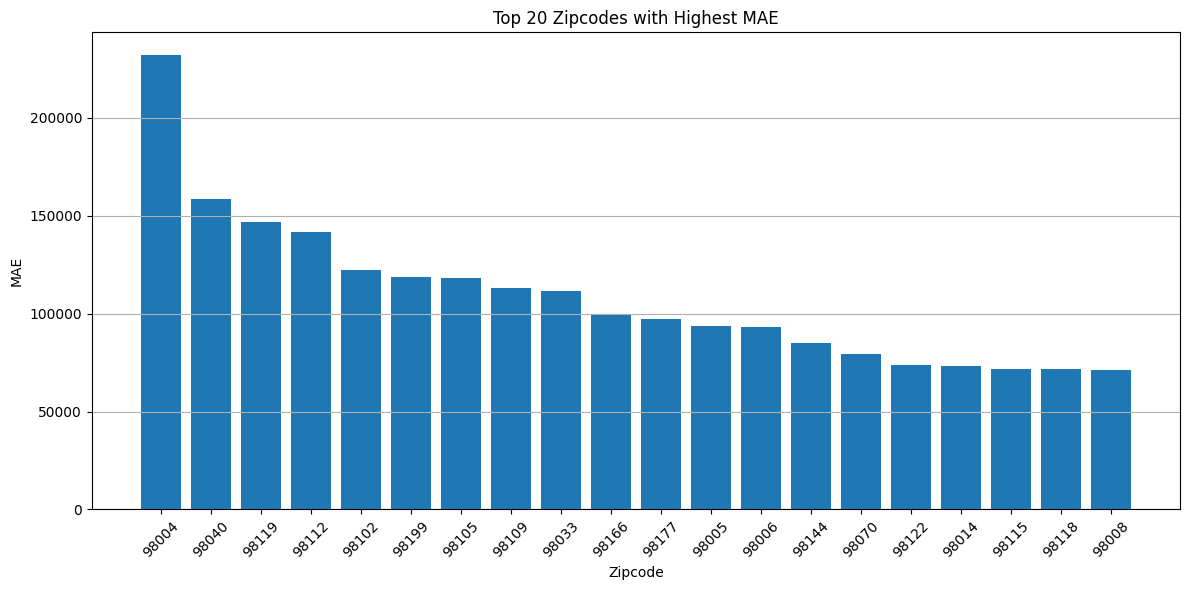

In [23]:
top_mae_zipcodes = zipcode_performance_stable.sort_values(
    "MAE",
    ascending=False
).head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_mae_zipcodes["zipcode"], top_mae_zipcodes["MAE"])
plt.xlabel("Zipcode")
plt.ylabel("MAE")
plt.title("Top 20 Zipcodes with Highest MAE")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## 17. Visualisation: Over-Prediction and Under-Prediction Bias

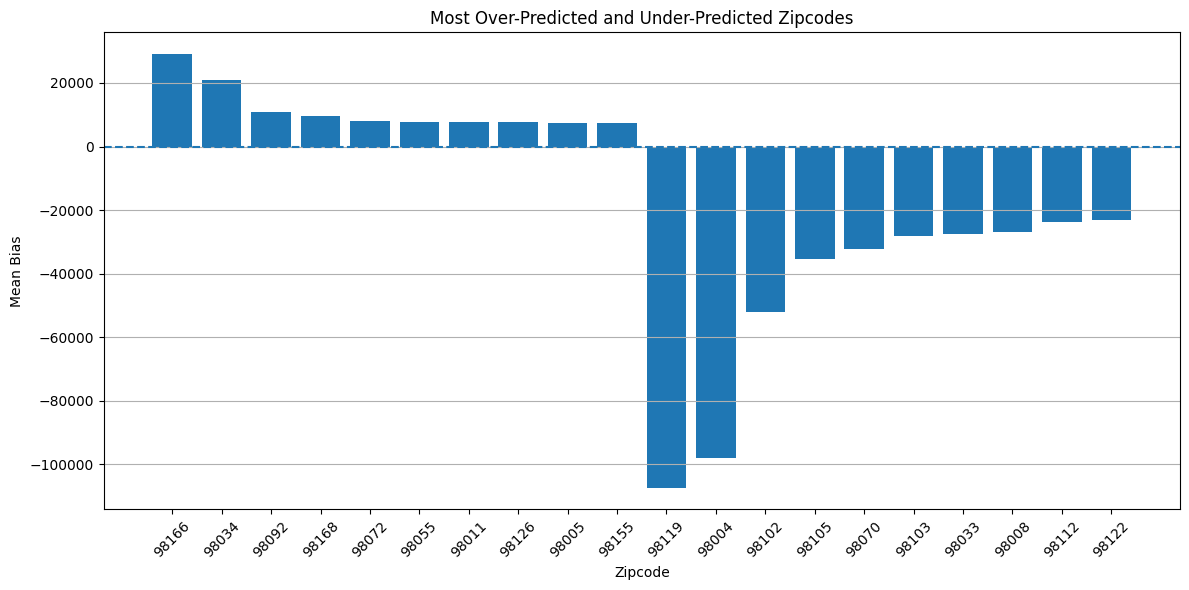

In [24]:
bias_zipcodes_positive = zipcode_performance_stable.sort_values(
    "mean_bias",
    ascending=False
).head(10)

bias_zipcodes_negative = zipcode_performance_stable.sort_values(
    "mean_bias",
    ascending=True
).head(10)

bias_plot_data = pd.concat([bias_zipcodes_positive, bias_zipcodes_negative])

plt.figure(figsize=(12, 6))
plt.bar(bias_plot_data["zipcode"], bias_plot_data["mean_bias"])
plt.axhline(0, linestyle="--")
plt.xlabel("Zipcode")
plt.ylabel("Mean Bias")
plt.title("Most Over-Predicted and Under-Predicted Zipcodes")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## 18. Summary Table for Location-Based Stability

In [25]:
overall_mape = location_result["percentage_error"].mean()
overall_mae = location_result["absolute_error"].mean()
overall_rmse = np.sqrt(location_result["squared_error"].mean())

summary = {
    "Overall MAE": overall_mae,
    "Overall RMSE": overall_rmse,
    "Overall MAPE (%)": overall_mape,
    "Number of zipcodes analysed": zipcode_performance_stable.shape[0],
    "Highest zipcode MAPE (%)": zipcode_performance_stable["MAPE"].max(),
    "Lowest zipcode MAPE (%)": zipcode_performance_stable["MAPE"].min(),
    "MAPE standard deviation across zipcodes": zipcode_performance_stable["MAPE"].std(),
    "MAE standard deviation across zipcodes": zipcode_performance_stable["MAE"].std(),
    "Highest over-prediction bias": zipcode_performance_stable["mean_bias"].max(),
    "Highest under-prediction bias": zipcode_performance_stable["mean_bias"].min()
}

summary_df = pd.DataFrame([summary])
display(summary_df)

,Overall MAE,Overall RMSE,Overall MAPE (%),Number of zipcodes analysed,Highest zipcode MAPE (%),Lowest zipcode MAPE (%),MAPE standard deviation across zipcodes,MAE standard deviation across zipcodes,Highest over-prediction bias,Highest under-prediction bias
0,64319.465134,120511.568898,11.669206,66,21.134482,6.801188,2.974535,37617.677146,29101.780976,-107341.466406


## 19. Automatic Interpretation Helper

This cell prints a short interpretation that can be used as a basis for the report.


In [28]:
mape_std = zipcode_performance_stable["MAPE"].std()
mape_mean = zipcode_performance_stable["MAPE"].mean()

print("Location-based fairness and stability interpretation")
print("---------------------------------------------------")
print(f"The overall test MAPE is {overall_mape:.2f}%.")
print(f"Across zipcodes with at least {min_samples} test samples, the average zipcode-level MAPE is {mape_mean:.2f}%.")
print(f"The standard deviation of MAPE across zipcodes is {mape_std:.2f} percentage points.")

worst_zip = worst_zipcodes.iloc[0]
best_zip = best_zipcodes.iloc[0]

print(f"\nThe zipcode with the highest MAPE is {worst_zip['zipcode']}, with a MAPE of {worst_zip['MAPE']:.2f}%.")
print(f"The zipcode with the lowest MAPE is {best_zip['zipcode']}, with a MAPE of {best_zip['MAPE']:.2f}%.")

most_over = over_predicted_zipcodes.iloc[0]
most_under = under_predicted_zipcodes.iloc[0]

print(f"\nThe most over-predicted zipcode is {most_over['zipcode']}, with an average bias of {most_over['mean_bias']:.2f}.")
print(f"The most under-predicted zipcode is {most_under['zipcode']}, with an average bias of {most_under['mean_bias']:.2f}.")

Location-based fairness and stability interpretation
---------------------------------------------------
The overall test MAPE is 11.67%.
Across zipcodes with at least 20 test samples, the average zipcode-level MAPE is 11.88%.
The standard deviation of MAPE across zipcodes is 2.97 percentage points.

The zipcode with the highest MAPE is 98146, with a MAPE of 21.13%.
The zipcode with the lowest MAPE is 98029, with a MAPE of 6.80%.

The most over-predicted zipcode is 98166, with an average bias of 29101.78.
The most under-predicted zipcode is 98119, with an average bias of -107341.47.
